In [24]:
#import libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

#load Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

<Axes: xlabel='job_title_short'>

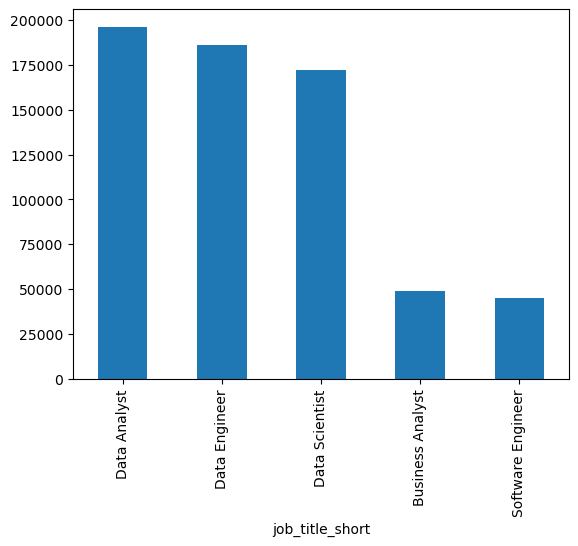

In [25]:
fig, ax = plt.subplots()

df['job_title_short'].value_counts().head(5).plot(kind = 'bar', ax = ax)

In [26]:
df['job_title_short'].value_counts().head(5)

job_title_short
Data Analyst         196075
Data Engineer        186241
Data Scientist       172286
Business Analyst      49063
Software Engineer     44929
Name: count, dtype: int64

In [27]:
df['job_schedule_type'].value_counts().head(3)

job_schedule_type
Full-time     701727
Contractor     34793
Internship      8742
Name: count, dtype: int64

## pandas plot

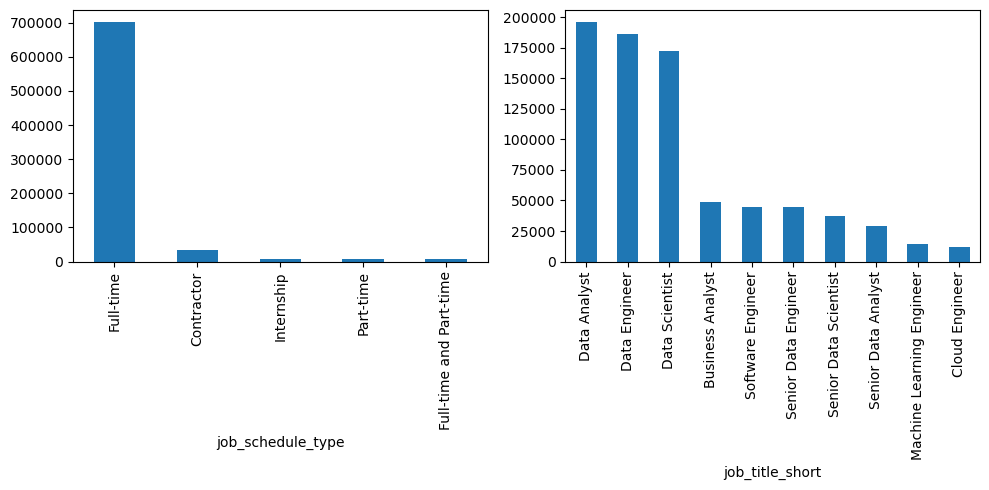

In [34]:
fig, ax = plt.subplots (1, 2, figsize = (10,5))
df['job_title_short'].value_counts().plot(kind = 'bar', ax=ax[1])
df['job_schedule_type'].value_counts().head().plot(kind = 'bar', ax=ax[0])

fig.tight_layout()

## matplotlib plot

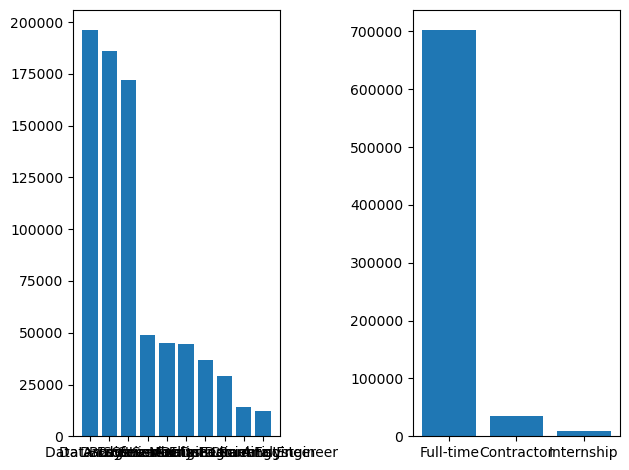

In [31]:
fig, ax = plt.subplots(1, 2)

ax[0].bar(df['job_title_short'].value_counts().index,
          df['job_title_short'].value_counts())

ax[1].bar(df['job_schedule_type'].value_counts().head(3).index,
          df['job_schedule_type'].value_counts().head(3))

plt.tight_layout()
plt.show()

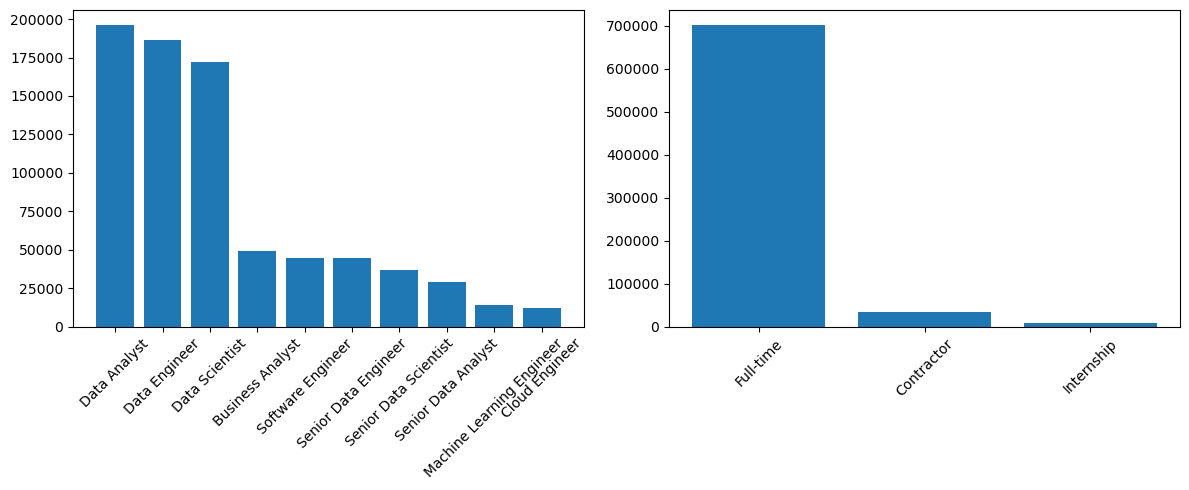

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

title_counts = df['job_title_short'].value_counts()
schedule_counts = df['job_schedule_type'].value_counts().head(3)

ax[0].bar(title_counts.index, title_counts)
ax[1].bar(schedule_counts.index, schedule_counts)

ax[0].tick_params(axis='x', rotation=45)
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [36]:
df_skills = df.copy()

df_skills = df_skills.explode('job_skills')

skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()

df_skills_count = skills_count.reset_index(name='skill_count')

df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)

df_skills_count

,job_skills,job_title_short,skill_count
1480,python,Data Scientist,113711
1822,sql,Data Engineer,113130
1479,python,Data Engineer,108022
1821,sql,Data Analyst,92428
1823,sql,Data Scientist,78982
...,...,...,...
2173,webex,Senior Data Scientist,1
293,codecommit,Business Analyst,1
2233,xamarin,Machine Learning Engineer,1
1087,mlr,Machine Learning Engineer,1


In [37]:
job_titles = ['Data Scientist','Data Engineer', 'Data Analyst']

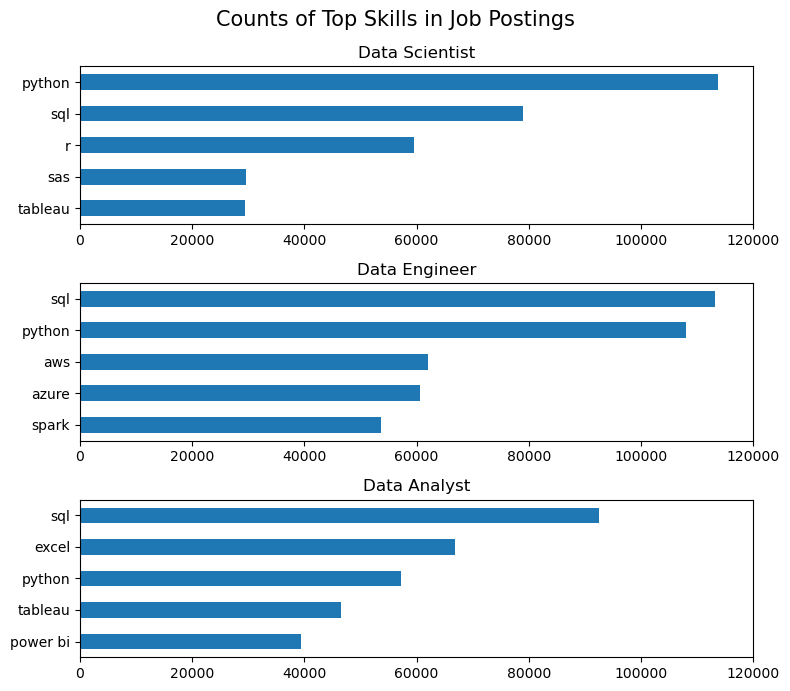

In [44]:
fig, ax = plt.subplots(3, 1, figsize=(8, 7))

for i, job_title in enumerate(job_titles):

    df_plot = df_skills_count[
        df_skills_count['job_title_short'] == job_title
    ].head(5)

    df_plot.plot(
        kind='barh',
        x='job_skills',
        y='skill_count',
        ax=ax[i],
        title=job_title
    )

    ax[i].invert_yaxis()
    ax[i].set_ylabel("")
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0, 120000)

fig.suptitle('Counts of Top Skills in Job Postings', fontsize=15)
fig.tight_layout()
plt.show()